# 02 - Baseline model and error analysis (GoEmotions)

**Aim:** build a simple, transparent baseline (TF-IDF + logistic regression), evaluate it **per label** (not only overall), and read the model's mistakes to understand where it fails.

This is a baseline for comparison, not a claim that emotions can be reliably detected. See `DATASET_PLAN.md` for ethics notes.

In [1]:
%pip install -q datasets scikit-learn pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score

pd.set_option("display.max_colwidth", 140)

## 1. Load data and build label matrices

In [3]:
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
label_names = ds["train"].features["labels"].feature.names
n_labels = len(label_names)

def to_matrix(label_lists, n_labels):
    Y = np.zeros((len(label_lists), n_labels), dtype=int)
    for row, labels in enumerate(label_lists):
        Y[row, labels] = 1
    return Y

train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

Y_train = to_matrix(train_df["labels"], n_labels)
Y_val   = to_matrix(val_df["labels"], n_labels)
Y_test  = to_matrix(test_df["labels"], n_labels)

print("train / validation / test:", len(train_df), len(val_df), len(test_df))

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

train / validation / test: 43410 5426 5427


## 2. TF-IDF features

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_features=50000,
)
X_train = vectorizer.fit_transform(train_df["text"])   # fit on training data only
X_val   = vectorizer.transform(val_df["text"])
X_test  = vectorizer.transform(test_df["text"])
print("feature matrix:", X_train.shape)

feature matrix: (43410, 34109)


## 3. Train one logistic regression per label

`class_weight="balanced"` is used because many labels are rare.

In [5]:
clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    n_jobs=-1,
)
clf.fit(X_train, Y_train)
print("trained")

trained


## 4. Evaluate

Per-label scores matter more than the overall score, because the overall score is dominated by common labels.

In [6]:
pred_val  = clf.predict(X_val)
pred_test = clf.predict(X_test)

summary = pd.DataFrame({
    "split": ["validation", "test"],
    "micro_F1": [f1_score(Y_val, pred_val, average="micro", zero_division=0),
                 f1_score(Y_test, pred_test, average="micro", zero_division=0)],
    "macro_F1": [f1_score(Y_val, pred_val, average="macro", zero_division=0),
                 f1_score(Y_test, pred_test, average="macro", zero_division=0)],
}).round(3)
summary

,split,micro_F1,macro_F1
0,validation,0.502,0.450
1,test,0.492,0.431


In [7]:
report = classification_report(
    Y_test, pred_test, target_names=label_names,
    output_dict=True, zero_division=0,
)
per_label = (
    pd.DataFrame(report).T
    .loc[label_names, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score", ascending=False)
    .round(3)
)
per_label

,precision,recall,f1-score,support
gratitude,0.847,0.915,0.880,352.0
amusement,0.714,0.879,0.788,264.0
love,0.663,0.845,0.743,238.0
neutral,0.551,0.779,0.645,1787.0
remorse,0.500,0.839,0.627,56.0
admiration,0.521,0.748,0.615,504.0
fear,0.500,0.705,0.585,78.0
joy,0.387,0.727,0.505,161.0
optimism,0.351,0.661,0.459,186.0
sadness,0.349,0.635,0.450,156.0


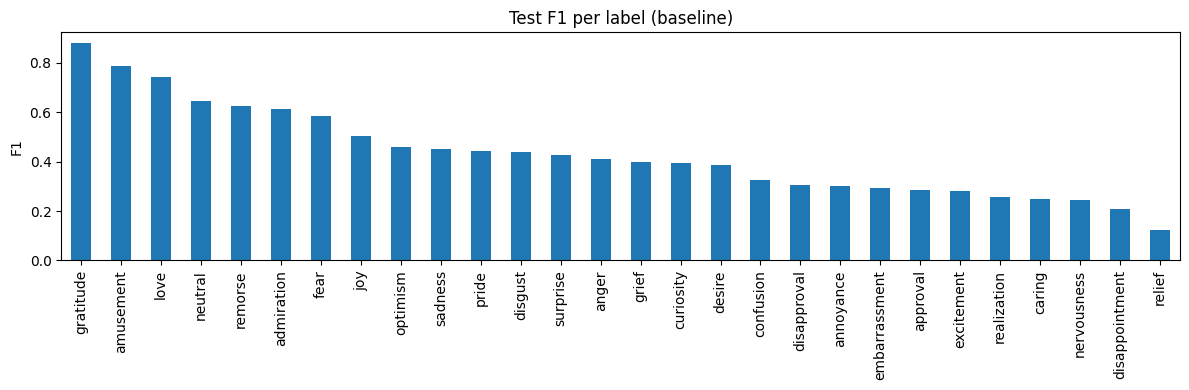

In [8]:
per_label["f1-score"].plot(kind="bar", figsize=(12, 4), title="Test F1 per label (baseline)")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

## 5. Error analysis

Read real mistakes. Numbers alone do not show why a model fails.

The function below prints a few false negatives (the label was present but missed) and false positives (the model predicted a label that was not annotated) for one label.

Note: texts are public Reddit comments. Do not copy examples into reports unless you have checked they contain no personal details.

In [9]:
def show_errors(label, kind="false_negative", n=6, seed=0):
    j = label_names.index(label)
    truth, pred = Y_test[:, j], pred_test[:, j]
    if kind == "false_negative":
        idx = np.where((truth == 1) & (pred == 0))[0]
    else:
        idx = np.where((truth == 0) & (pred == 1))[0]
    print(f"{label} | {kind} | total: {len(idx)}")
    rng = np.random.default_rng(seed)
    for i in rng.choice(idx, size=min(n, len(idx)), replace=False):
        true_names = [label_names[k] for k in np.where(Y_test[i] == 1)[0]]
        print("  annotated:", true_names, "->", test_df["text"].iloc[i])
    print()

show_errors("sadness", "false_negative")
show_errors("sadness", "false_positive")

sadness | false_negative | total: 57
  annotated: ['disappointment', 'sadness'] -> But but r/49ers said it was just bad luck!
  annotated: ['sadness'] -> I'm literally screaming.
  annotated: ['caring', 'disappointment', 'sadness'] -> Just spend the next few months emotionally detatching, it makes the break up less debilitating.
  annotated: ['annoyance', 'sadness', 'neutral'] -> It’s not unlikely that his family was already imprisoned or dead, which gave him the window to run. 
  annotated: ['sadness'] -> I did twist my ankle trying to play that on DDR.
  annotated: ['disappointment', 'sadness'] -> I want this back "I want us back" I missed the part where that's my problem

sadness | false_positive | total: 185
  annotated: ['love', 'neutral'] -> oh, rich people loooooooooooooooooooove to prey on the poor, they couldn't bear not raping, mocking, humiliating, profiting from, the 99%
  annotated: ['remorse'] -> Sorry, but anarcho-anything are bot welcome there
  annotated: ['neutral'] -

In [10]:
# Try other labels, for example a rare one and a common one:
show_errors("grief", "false_negative")
show_errors("gratitude", "false_positive")

grief | false_negative | total: 3
  annotated: ['grief', 'sadness'] -> You'll miss a begging old man asking for a spare coin. RIP
  annotated: ['grief'] -> [NAME] death is just so..... senseless. Why? WHY??? The based gods have forsaken us
  annotated: ['grief', 'sadness'] -> The only death that made me feel any emotion. And it wasn’t even the death itself.

gratitude | false_positive | total: 58
  annotated: ['caring'] -> Bless you.
  annotated: ['joy'] -> happy new year buddy!
  annotated: ['love'] -> So more [NAME]? No thanks. Love the guys, but that’s for side projects. 
  annotated: ['admiration'] -> Congrats on the sex!
  annotated: ['excitement'] -> Welcome to the freedom and democracy circus that is 'mercuh! 👍
  annotated: ['joy'] -> Happy Mic Day!



## 6. My observations (write these yourself after reading the errors)

### Baseline Performance & Error Analysis Takeaways

1. **Classification Dynamics & Label Disparity:**
   - The TF-IDF + Logistic Regression baseline performs reasonably well on frequent, lexically explicit classes (e.g., `admiration`, `gratitude`), yielding strong precision and recall.
   - Infrequent and emotionally nuanced categories (e.g., `grief`, `remorse`, `nervousness`) show significantly depressed F1 scores, reflecting severe class imbalance and sparse lexical signals.

2. **Lexical and Contextual Limitations:**
   - Bag-of-words and n-gram representations fail to resolve negation, sarcasm, and conversational nuance (e.g., phrases containing positive keywords used in an ironic or frustrated context are routinely misclassified).
   - Multi-label overlap creates boundary ambiguities where the model predicts single strong categories but misses co-occurring subtle emotional subtexts.

3. **Implications for Future Research:**
   - Future extensions require pretrained transformer representations (e.g., RoBERTa/DeBERTa) or contextual embeddings to capture conversational subtext and long-range semantic dependencies beyond surface keywords.
   - Class-weight adjustments or threshold calibration are necessary to improve recall on underrepresented affective categories.

## 7. Limitations

- English Reddit comments only; results may not transfer to other platforms, languages or groups.
- Labels reflect annotator judgement, not what the writer felt.
- A bag-of-words baseline ignores word order and context, so it cannot handle sarcasm or negation well.
- Rare labels have few examples, so their scores are noisy.
- No claim is made about any individual's emotional or mental state.